# The small run, stage by stage

d=3, 12 rounds, 3 sliding windows, seed 8: one detector fires in round 11
and the observable really flips. Every cost is a whole number of
microseconds (round period 3, every stage 1, fetch 3), so every timestamp
below is a whole number you can check in your head. First the run is
assembled piece by piece, straight from decsim; then each cell prints what
one stage receives and what it sends on, with timestamps. Hand formulas:
README section 1.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "guide" / "walkthrough"))
sys.path.insert(0, str(repo_root))
print(repo_root)

/scratch/gpfs/MARTONOSI/sk2415/qlx-qec-sandbox/decsim


## The yaml: every cost of the experiment, all whole microseconds

In [2]:
import yaml

CONFIG_PATH = repo_root / "guide/walkthrough/small_run.yaml"
config = yaml.safe_load(CONFIG_PATH.read_text())
print(CONFIG_PATH.read_text())

# The walkthrough's small run: every cost a whole number of microseconds,
# so every timestamp of the run is a whole number you can check in your head.
#
#   round period 3, qc 1, c2b 1, cwd 1, fetch 3 (6 rounds x 0.5), algorithm 1,
#   release 1, dd 1, wdo 1, frame commit 1
#
# This is a teaching card, not a hardware claim. The engine runs at 2 MHz
# only because a 0.5 µs cycle makes fetch (1 cycle per round) and release
# (2 cycles) come out whole. The reference-card case with real numbers is
# experiments/validation/analytic_oracle_d3_r12.yaml.

code_task: surface_code:rotated_memory_z
distance: 3
rounds_per_shot: 12

windowing:
  scheme: sliding
  commit_rounds: 3
  buffer_rounds: 3

sweep:
  # p = 0 exactly cannot run: a noiseless circuit has an empty detector error
  # model and no matching graph. 1.0e-9 samples zero defects; the notebook
  # raises p to 0.001 so a real defect flows (timing is unchanged either way).
  - physical_error_probability: [1.0e-9]
    round_period_us: [3

## Assemble the run, piece 1: the circuit and the operation

The yaml uses p = 1e-9 (zero defects); here p = 0.001 so a real defect
flows through the pipeline. Timing does not change: every stage cost is a
preset card.

In [3]:
import stim

from decsim.message import Operation

sweep = config["sweep"][0]
physical_error_probability = 0.001

circuit = stim.Circuit.generated(
    config["code_task"],
    rounds=config["rounds_per_shot"],
    distance=config["distance"],
    after_clifford_depolarization=physical_error_probability,
    before_round_data_depolarization=physical_error_probability,
    before_measure_flip_probability=physical_error_probability,
    after_reset_flip_probability=physical_error_probability)

operation = Operation(id=1, name="memory", qubits=(0,), patches=(0,), circuit=circuit)
print("circuit:", len(circuit), "instructions,", circuit.num_detectors, "detectors,",
      circuit.num_observables, "observable")

circuit: 56 instructions, 96 detectors, 1 observable


## Piece 2: the weak decoder

PyMatching inside the decoder engine: fetch cycles before it, release
cycles after it, at the engine clock. The 1 µs card prices the algorithm
stage only.

In [4]:
from decsim.decoders.decoder_engine import DecoderEngine, DecoderStage, DecoderTiming
from decsim.decoders.decoders import PresetLatencyDecoder
from decsim.decoders.mwpm.decoder import PyMatchingDecoder

algorithm = PyMatchingDecoder(PresetLatencyDecoder(sweep["algorithm_latency_us"][0]))

engine_card = config["decoder"]["engine"]
fetch = DecoderStage("fetch", cycles_per_round=engine_card["fetch_cycles_per_round"])
release = DecoderStage("release", cycles_per_job=engine_card["release_cycles_per_job"])
timing_card = DecoderTiming(before=(fetch,), after=(release,),
                            frequency_mhz=engine_card["frequency_mhz"])

decoder_engine = DecoderEngine(algorithm, timing_card)
print("engine at", engine_card["frequency_mhz"], "MHz (0.5 µs cycle):",
      "fetch 1 cycle per round (6 rounds = 3 µs),",
      "algorithm", sweep["algorithm_latency_us"][0], "µs,",
      "release 2 cycles (1 µs)")

engine at 2.0 MHz (0.5 µs cycle): fetch 1 cycle per round (6 rounds = 3 µs), algorithm 1.0 µs, release 2 cycles (1 µs)


## Piece 3: the links

Start from the reference card, price the C2B edge, then set each yaml
card's latency. Capacity None means unbounded bandwidth: propagation only.

In [5]:
from dataclasses import replace

from decsim.config import us as ticks_of
from decsim.links.link_profiles import logical_reference_profile, with_controller_to_buffer_edge
from decsim.links.links import LinkConfig

cards = config["links"]
source = "small_run.yaml"

links = with_controller_to_buffer_edge(logical_reference_profile(),
                                       latency_us=cards["c2b"]["latency_us"],
                                       aggregate_bits_per_us=cards["c2b"]["bits_per_us"],
                                       source=source)
for path in ("qc", "cwd", "dd", "wdo"):
    channel = LinkConfig(ticks_of(cards[path]["latency_us"]), None, source)
    edge = replace(getattr(links, path), channel=channel)
    links = replace(links, **{path: edge})

for path in ("qc", "c2b", "cwd", "dd", "wdo"):
    edge = getattr(links, path)
    print(path, "latency:", edge.channel.propagation_latency_ticks / 1_000_000, "µs")

qc latency: 1.0 µs
c2b latency: 1.0 µs
cwd latency: 1.0 µs
dd latency: 1.0 µs
wdo latency: 1.0 µs


## Piece 4: the run spec, and run it

The code geometry, the sliding windows, the round period, the Pauli frame:
everything meets in one RunSpec.

In [6]:
from decsim.config import TimingConfig
from decsim.pauli_frame.pauli_frame import PauliFrameConfig
from decsim.qpu.code_geometry import SurfaceCodeModel
from decsim.qpu.round_policies import FixedRounds
from decsim.qpu.stim_device import StimDevice
from decsim.run_spec import RunSpec
from decsim.windows.windowing_schemes import SlidingWindowScheme

code_model = SurfaceCodeModel(d=config["distance"],
                              commit_rounds_override=config["windowing"]["commit_rounds"],
                              buffer_rounds_override=config["windowing"]["buffer_rounds"])
timing = TimingConfig(round_us=sweep["round_period_us"][0],
                      t_binary_availability_us=config["controller"]["t_binary_availability_us"],
                      t_pack_us=config["controller"]["t_pack_us"])

spec = RunSpec(ops=[operation],
               code=code_model,
               scheme=SlidingWindowScheme(),
               rounds_policy=FixedRounds(config["rounds_per_shot"]),
               device=StimDevice(),
               decoder=decoder_engine,
               num_units=config["decoder"]["units"],
               timing=timing,
               links=links,
               pauli_frame=PauliFrameConfig(commit_us=config["pauli_frame"]["commit_us"]),
               seed=8)

completed = spec.build()
print(completed.result.terminal_status)

complete


## The records the run left behind (every cell below only reads these)

In [7]:
from decsim.config import TICKS_PER_US

transfers = completed.result.link_traffic["transfers"]
windows = {window_id: window
           for (_, window_id), window in sorted(completed.window_manager.windows.items())}
frame_records = {record.window_key[1]: record
                 for record in completed.pauli_frame.snapshot().records}
qpu = completed.qpu.model


def us(ticks):
    value = ticks / TICKS_PER_US
    if value == int(value):
        return int(value)
    return round(value, 6)


def transfers_on(path):
    """round -> transfer for qc and c2b, window -> transfer for the rest."""
    selected = {}
    for transfer in transfers:
        if transfer["path"] != path:
            continue
        if path in ("qc", "c2b"):
            selected[transfer["attribution"]["round_lo"]] = transfer
        else:
            selected[transfer["attribution"]["window_id"]] = transfer
    return selected


qc = transfers_on("qc")
c2b = transfers_on("c2b")
cwd = transfers_on("cwd")
dd = transfers_on("dd")
wdo = transfers_on("wdo")


def bits_of_round(round_index):
    fragment = qpu.round_payloads(operation, round_index)[0]
    return "".join(str(int(bit)) for bit in fragment.bits)


print("paths that carried traffic:", sorted({t["path"] for t in transfers}))

paths that carried traffic: ['c2b', 'cwd', 'dd', 'qc', 'wdo']


## Stage 1: the QPU

IN: the circuit below, one round every 3 µs (the controller sends the QPU
nothing at runtime, there is no cq traffic). OUT: one readout per round,
that round's detector bits, leaving at 3, 6, ..., 36 µs.

In [8]:
print(operation.circuit)

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.001) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.001) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.001) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.001) 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
DEPOLARIZE2(0.001) 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
X

In [9]:
for round_index in sorted(qc):
    time_sent = us(qc[round_index]["send_ticks"])
    print("round", round_index, "leaves QPU at", time_sent, "µs  bits:", bits_of_round(round_index))

round 1 leaves QPU at 3 µs  bits: 0000
round 2 leaves QPU at 6 µs  bits: 00000000
round 3 leaves QPU at 9 µs  bits: 00000000
round 4 leaves QPU at 12 µs  bits: 00000000
round 5 leaves QPU at 15 µs  bits: 00000000
round 6 leaves QPU at 18 µs  bits: 00000000
round 7 leaves QPU at 21 µs  bits: 00000000
round 8 leaves QPU at 24 µs  bits: 00000000
round 9 leaves QPU at 27 µs  bits: 00000000
round 10 leaves QPU at 30 µs  bits: 00000000
round 11 leaves QPU at 33 µs  bits: 00010000
round 12 leaves QPU at 36 µs  bits: 000000000000


## Stage 2: the QC link

IN: the readout at its send time. OUT: the same bits at the controller
1 µs later.

In [10]:
for round_index in sorted(qc):
    transfer = qc[round_index]
    sent = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("round", round_index, "sent", sent, "µs  at controller", arrived, "µs")

round 1 sent 3 µs  at controller 4 µs
round 2 sent 6 µs  at controller 7 µs
round 3 sent 9 µs  at controller 10 µs
round 4 sent 12 µs  at controller 13 µs
round 5 sent 15 µs  at controller 16 µs
round 6 sent 18 µs  at controller 19 µs
round 7 sent 21 µs  at controller 22 µs
round 8 sent 24 µs  at controller 25 µs
round 9 sent 27 µs  at controller 28 µs
round 10 sent 30 µs  at controller 31 µs
round 11 sent 33 µs  at controller 34 µs
round 12 sent 36 µs  at controller 37 µs


## Stage 3: controller processing (pulses to binary)

t_binary_availability_us is 0 in this yaml, so the bits are
binary-available the moment they arrive.

In [11]:
print("t_binary_availability_us =", config["controller"]["t_binary_availability_us"])
arrived = us(qc[11]["delivery_ticks"])
print("round 11 arrived at", arrived, "µs and is binary-available at", arrived, "µs")

t_binary_availability_us = 0.0
round 11 arrived at 34 µs and is binary-available at 34 µs


## Stage 4: syndrome packing

IN: the round's fragments (this device emits one per round, so nothing
waits). OUT: one packed round, same bits, at the same time (t_pack 0).

In [12]:
print("t_pack_us =", config["controller"]["t_pack_us"])
for round_index in sorted(qc):
    fragment = qpu.round_payloads(operation, round_index)[0]
    packed_at = us(c2b[round_index]["send_ticks"])
    print("round", round_index, "fragments in:", fragment.n_fragments,
          " bits:", bits_of_round(round_index), " packed at", packed_at, "µs")

t_pack_us = 0.0
round 1 fragments in: 1  bits: 0000  packed at 4 µs
round 2 fragments in: 1  bits: 00000000  packed at 7 µs
round 3 fragments in: 1  bits: 00000000  packed at 10 µs
round 4 fragments in: 1  bits: 00000000  packed at 13 µs
round 5 fragments in: 1  bits: 00000000  packed at 16 µs
round 6 fragments in: 1  bits: 00000000  packed at 19 µs
round 7 fragments in: 1  bits: 00000000  packed at 22 µs
round 8 fragments in: 1  bits: 00000000  packed at 25 µs
round 9 fragments in: 1  bits: 00000000  packed at 28 µs
round 10 fragments in: 1  bits: 00000000  packed at 31 µs
round 11 fragments in: 1  bits: 00010000  packed at 34 µs
round 12 fragments in: 1  bits: 000000000000  packed at 37 µs


## Stage 5: the C2B link into Buffer 0

IN: the packed round. OUT: the round published in Buffer 0 1 µs later.
Every round is published 2 µs after it left the QPU (qc 1 + c2b 1): links
shift the phase, never the rate.

In [13]:
for round_index in sorted(c2b):
    left_qpu = us(qc[round_index]["send_ticks"])
    published = us(c2b[round_index]["delivery_ticks"])
    print("round", round_index, "left QPU", left_qpu, "µs  published in Buffer 0", published, "µs")

round 1 left QPU 3 µs  published in Buffer 0 5 µs
round 2 left QPU 6 µs  published in Buffer 0 8 µs
round 3 left QPU 9 µs  published in Buffer 0 11 µs
round 4 left QPU 12 µs  published in Buffer 0 14 µs
round 5 left QPU 15 µs  published in Buffer 0 17 µs
round 6 left QPU 18 µs  published in Buffer 0 20 µs
round 7 left QPU 21 µs  published in Buffer 0 23 µs
round 8 left QPU 24 µs  published in Buffer 0 26 µs
round 9 left QPU 27 µs  published in Buffer 0 29 µs
round 10 left QPU 30 µs  published in Buffer 0 32 µs
round 11 left QPU 33 µs  published in Buffer 0 35 µs
round 12 left QPU 36 µs  published in Buffer 0 38 µs


## Stage 6: the window manager

IN: the published rounds. OUT: one decode job per window, whose data is
its rounds' bits side by side. Window 2's bits contain the fired bit. A
window is ready when its last round is published, queued when the previous
window's DD handoff has arrived, dispatched when the unit is free.

In [14]:
last_round = config["rounds_per_shot"]

window_bits = {}
for window_id, window in windows.items():
    first_round = window.start_round
    final_round = min(window.buffer_hi, last_round)
    rounds = range(first_round, final_round + 1)
    window_bits[window_id] = "".join(bits_of_round(round_index) for round_index in rounds)
    print("window", window_id, "reads rounds", first_round, "to", final_round,
          " commits", window.commit_lo, "to", window.commit_hi)
    print("  bits:", window_bits[window_id])
    print("  ready", us(window.t_data_complete), "µs  queued", us(window.t_queued),
          "µs  dispatch", us(window.t_dispatch), "µs")

window 0 reads rounds 1 to 6  commits 1 to 3
  bits: 00000000000000000000000000000000000000000000
  ready 20 µs  queued 20 µs  dispatch 20 µs
window 1 reads rounds 4 to 9  commits 4 to 6
  bits: 000000000000000000000000000000000000000000000000
  ready 29 µs  queued 29 µs  dispatch 29 µs
window 2 reads rounds 7 to 12  commits 7 to 12
  bits: 0000000000000000000000000000000000010000000000000000
  ready 38 µs  queued 38 µs  dispatch 38 µs


## Stage 7: the CWD link into decoder memory

IN: the dispatched window's bits out of Buffer 0. OUT: the same bits in
the decoder unit's memory 1 µs later.

In [15]:
for window_id in windows:
    transfer = cwd[window_id]
    left = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("window", window_id, "bits:", transfer["payload_bits"],
          " left Buffer 0", left, "µs  in decoder memory", arrived, "µs")

window 0 bits: 44  left Buffer 0 20 µs  in decoder memory 21 µs
window 1 bits: 48  left Buffer 0 29 µs  in decoder memory 30 µs
window 2 bits: 52  left Buffer 0 38 µs  in decoder memory 39 µs


## Stage 8: the decoder engine

IN: the window's bits. Fetch reads the 6 rounds out of memory at 0.5 µs
each (3 µs), the algorithm card charges 1 µs, release writes the result
out in 1 µs. OUT: the window's correction. Window 2 saw the fired bit and
outputs 1.

In [16]:
for window_id in windows:
    for record in decoder_engine.stage_records_for(operation.id, window_id):
        print("window", window_id, record.stage, "from", us(record.start_ticks),
              "to", us(record.end_ticks), "µs")
    correction = frame_records[window_id].logical_observables
    print("window", window_id, "correction:", correction)
    print()

window 0 fetch from 21 to 24 µs
window 0 algorithm from 24 to 25 µs
window 0 release from 25 to 26 µs
window 0 correction: (0,)

window 1 fetch from 30 to 33 µs
window 1 algorithm from 33 to 34 µs
window 1 release from 34 to 35 µs
window 1 correction: (0,)

window 2 fetch from 39 to 42 µs
window 2 algorithm from 42 to 43 µs
window 2 release from 43 to 44 µs
window 2 correction: (1,)



## Stage 9: the DD handoff

OUT: the decoded window's boundary to the next window's decode, 1 µs after
decode done. Its delivery is the dependency arrival shown in stage 6. The
last window has no successor.

In [17]:
for window_id in windows:
    if window_id not in dd:
        print("window", window_id, "is last, no handoff")
        continue
    transfer = dd[window_id]
    sent = us(transfer["send_ticks"])
    delivered = us(transfer["delivery_ticks"])
    print("window", window_id, "sent", sent, "µs  delivered to next window", delivered, "µs")

window 0 sent 26 µs  delivered to next window 27 µs
window 1 sent 35 µs  delivered to next window 36 µs
window 2 is last, no handoff


## Stage 10: the WDO link

OUT: the correction at the Pauli frame, 1 µs after decode done.

In [18]:
for window_id, record in sorted(frame_records.items()):
    transfer = wdo[window_id]
    sent = us(transfer["send_ticks"])
    arrived = us(transfer["delivery_ticks"])
    print("window", window_id, "correction", record.logical_observables,
          " sent", sent, "µs  at frame", arrived, "µs")

window 0 correction (0,)  sent 26 µs  at frame 27 µs
window 1 correction (0,)  sent 35 µs  at frame 36 µs
window 2 correction (1,)  sent 44 µs  at frame 45 µs


## Stage 11: the Pauli frame

IN: the corrections, in window order. OUT: the running frame, the XOR of
everything committed so far, finalized 1 µs after each acceptance. The
final frame is the loop's prediction; it equals the QPU's sampled truth,
so the flipped observable was decoded correctly.

In [19]:
frame = 0
for window_id, record in sorted(frame_records.items()):
    frame = frame ^ record.logical_observables[0]
    print("window", window_id, "correction", record.logical_observables,
          " committed at", us(record.committed_ticks), "µs  frame is now", (frame,))

result = completed.result.operation_results[0]
print()
print("loop prediction:", tuple(result.logical_observables))
print("observable truth:", tuple(result.observable_truth))

window 0 correction (0,)  committed at 28 µs  frame is now (0,)
window 1 correction (0,)  committed at 37 µs  frame is now (0,)
window 2 correction (1,)  committed at 46 µs  frame is now (1,)

loop prediction: (1,)
observable truth: (1,)


## Latency breakdown, the full path

Every stage of one window's reaction, from its last round leaving the QPU
to the correction committed in the frame. All three windows are identical:
10 µs, with no waiting anywhere, and every segment a whole microsecond
(fetch is 3).

In [20]:
import matplotlib.pyplot as plt


def breakdown(window_id):
    """(stage, duration in µs) along the full path of this window."""
    window = windows[window_id]
    last_read_round = min(window.buffer_hi, last_round)
    stages = {record.stage: record
              for record in decoder_engine.stage_records_for(operation.id, window_id)}
    frame_record = frame_records[window_id]
    return [
        ("qc link", us(qc[last_read_round]["delivery_ticks"] - qc[last_read_round]["send_ticks"])),
        ("binary + packing", us(c2b[last_read_round]["send_ticks"] - qc[last_read_round]["delivery_ticks"])),
        ("c2b link", us(c2b[last_read_round]["delivery_ticks"] - c2b[last_read_round]["send_ticks"])),
        ("wait for dependency and unit", us(window.t_dispatch - window.t_data_complete)),
        ("cwd link", us(cwd[window_id]["delivery_ticks"] - cwd[window_id]["send_ticks"])),
        ("fetch", us(stages["fetch"].end_ticks - stages["fetch"].start_ticks)),
        ("algorithm", us(stages["algorithm"].end_ticks - stages["algorithm"].start_ticks)),
        ("release", us(stages["release"].end_ticks - stages["release"].start_ticks)),
        ("wdo link", us(wdo[window_id]["delivery_ticks"] - wdo[window_id]["send_ticks"])),
        ("frame commit", us(frame_record.committed_ticks - frame_record.accepted_ticks)),
    ]


for window_id in windows:
    print("window", window_id)
    for stage, duration in breakdown(window_id):
        print("  ", stage, duration, "µs")

window 0
   qc link 1 µs
   binary + packing 0 µs
   c2b link 1 µs
   wait for dependency and unit 0 µs
   cwd link 1 µs
   fetch 3 µs
   algorithm 1 µs
   release 1 µs
   wdo link 1 µs
   frame commit 1 µs
window 1
   qc link 1 µs
   binary + packing 0 µs
   c2b link 1 µs
   wait for dependency and unit 0 µs
   cwd link 1 µs
   fetch 3 µs
   algorithm 1 µs
   release 1 µs
   wdo link 1 µs
   frame commit 1 µs
window 2
   qc link 1 µs
   binary + packing 0 µs
   c2b link 1 µs
   wait for dependency and unit 0 µs
   cwd link 1 µs
   fetch 3 µs
   algorithm 1 µs
   release 1 µs
   wdo link 1 µs
   frame commit 1 µs


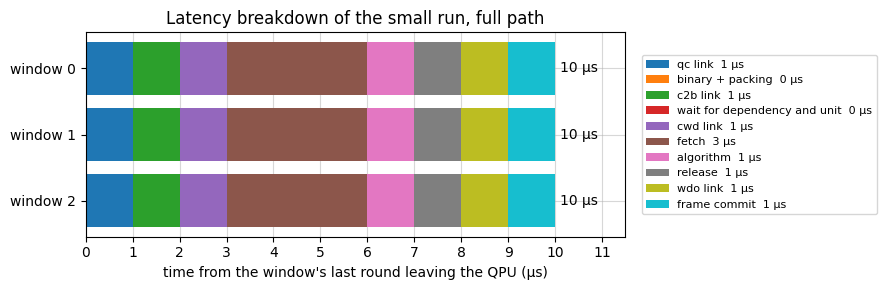

In [21]:
figure, axis = plt.subplots(figsize=(9, 3))
colors = plt.cm.tab10.colors

for row, window_id in enumerate(windows):
    start = 0
    for stage_index, (stage, duration) in enumerate(breakdown(window_id)):
        label = None
        if row == 0:
            label = stage + "  " + str(duration) + " µs"
        axis.barh(row, duration, left=start, color=colors[stage_index], label=label)
        start = start + duration
    axis.text(start + 0.1, row, str(start) + " µs", va="center")

axis.set_yticks(range(len(windows)))
axis.set_yticklabels(["window " + str(window_id) for window_id in windows])
axis.invert_yaxis()
axis.set_xticks(range(12))
axis.set_xlim(0, 11.5)
axis.grid(alpha=0.5, linewidth=0.8)
axis.set_axisbelow(True)
axis.set_xlabel("time from the window's last round leaving the QPU (µs)")
axis.set_title("Latency breakdown of the small run, full path")
axis.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
figure.tight_layout()
figure.savefig(repo_root / "guide" / "walkthrough" / "figures" / "small_run_breakdown.png", dpi=200)
plt.show()

## The whole run on one timeline

Every stage of the whole shot at its real time, nothing lumped: the gray
ingress rows carry one bar per round, the colored rows one bar per window,
each window in its own thin lane. The pipelining is visible: window 1's
buffer is filling while window 0 decodes. The right margin labels window
0's durations; windows 1 and 2 are identical, one and two window periods
(9 µs) later.

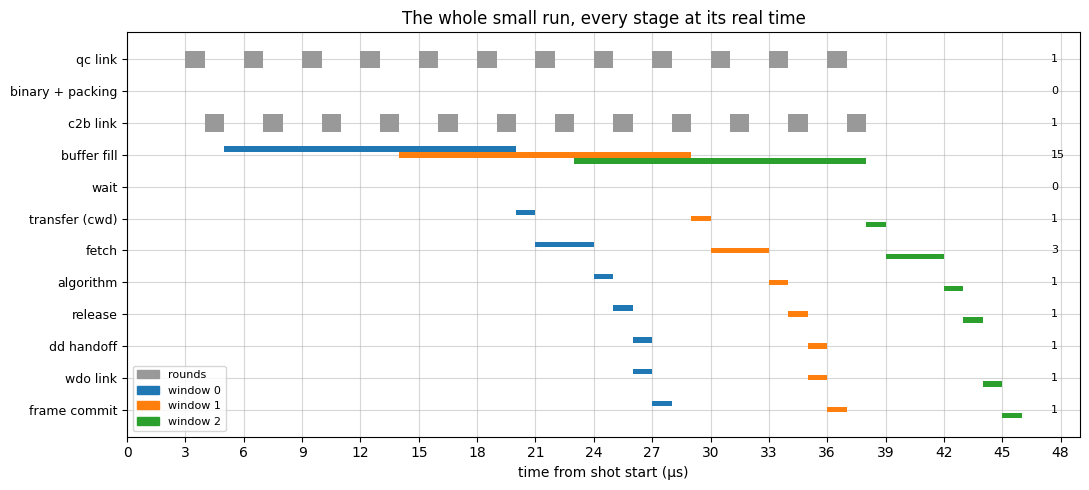

In [22]:
ROWS = ("qc link", "binary + packing", "c2b link", "buffer fill", "wait",
        "transfer (cwd)", "fetch", "algorithm", "release", "dd handoff",
        "wdo link", "frame commit")
WINDOW_COLORS = ("tab:blue", "tab:orange", "tab:green")

figure, axis = plt.subplots(figsize=(11, 5))


def bar(row, start, end, color):
    axis.barh(row, end - start, left=start, color=color, height=0.55)
    return end - start


for round_index in sorted(qc):
    bar(0, us(qc[round_index]["send_ticks"]), us(qc[round_index]["delivery_ticks"]), "0.6")
    bar(2, us(c2b[round_index]["send_ticks"]), us(c2b[round_index]["delivery_ticks"]), "0.6")

for window_id, window in windows.items():
    color = WINDOW_COLORS[window_id]

    # windows can overlap in time on the same row, so each window gets its
    # own thin lane inside the row
    def bar(row, start, end, color, window_id=window_id):
        lane = row + (window_id - 1) * 0.19
        axis.barh(lane, end - start, left=start, color=color, height=0.17)
        return end - start

    stages = {record.stage: record
              for record in decoder_engine.stage_records_for(operation.id, window_id)}
    durations = {}
    durations["qc link"] = 1
    durations["binary + packing"] = 0
    durations["c2b link"] = 1
    durations["buffer fill"] = bar(3, us(window.t_first_round), us(window.t_data_complete), color)
    durations["wait"] = bar(4, us(window.t_data_complete), us(window.t_dispatch), color)
    durations["transfer (cwd)"] = bar(5, us(cwd[window_id]["send_ticks"]),
                                      us(cwd[window_id]["delivery_ticks"]), color)
    for row, stage in ((6, "fetch"), (7, "algorithm"), (8, "release")):
        durations[stage] = bar(row, us(stages[stage].start_ticks), us(stages[stage].end_ticks), color)
    if window_id in dd:
        durations["dd handoff"] = bar(9, us(dd[window_id]["send_ticks"]),
                                      us(dd[window_id]["delivery_ticks"]), color)
    durations["wdo link"] = bar(10, us(wdo[window_id]["send_ticks"]),
                                us(wdo[window_id]["delivery_ticks"]), color)
    durations["frame commit"] = bar(11, us(frame_records[window_id].accepted_ticks),
                                    us(frame_records[window_id].committed_ticks), color)
    if window_id == 0:
        for row, name in enumerate(ROWS):
            if name in durations:
                axis.text(47.5, row, str(durations[name]), va="center", fontsize=8)

axis.set_yticks(range(len(ROWS)))
axis.set_yticklabels(ROWS, fontsize=9)
axis.invert_yaxis()
axis.set_xticks(range(0, 49, 3))
axis.set_xlim(0, 49)
axis.set_xlabel("time from shot start (µs)")
axis.set_title("The whole small run, every stage at its real time")
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in ("0.6",) + WINDOW_COLORS]
axis.legend(handles, ("rounds", "window 0", "window 1", "window 2"),
            loc="lower left", fontsize=8)
axis.grid(alpha=0.5, linewidth=0.8)
axis.set_axisbelow(True)
figure.tight_layout()
figure.savefig(repo_root / "guide" / "walkthrough" / "figures" / "small_run_timeline.png", dpi=200)
plt.show()

## End to end, against the hand arithmetic

This run condensed to one row per window, next to README section 1's
closed-form answer key. The defect changed the data, not one timestamp.

In [23]:
from analytic_small_run import COLUMNS, analytic_timeline, print_table

run_rows = []
for window_id, window in windows.items():
    record = frame_records[window_id]
    dd_delivery = None
    if window_id in dd:
        dd_delivery = us(dd[window_id]["delivery_ticks"])
    run_rows.append({
        "window_id": window_id,
        "read_lo": window.start_round,
        "read_hi": min(window.buffer_hi, last_round),
        "commit_lo": window.commit_lo,
        "commit_hi": window.commit_hi,
        "buffer0_ready_us": us(window.t_data_complete),
        "queued_us": us(window.t_queued),
        "dispatch_us": us(window.t_dispatch),
        "decode_done_us": us(window.t_done),
        "dd_delivery_us": dd_delivery,
        "frame_commit_us": us(record.committed_ticks),
        "buffer0_ready_to_frame_us": us(record.committed_ticks - window.t_data_complete),
    })

hand_rows = analytic_timeline(config)
print("This run:")
print_table(run_rows)
print()
print("By hand:")
print_table(hand_rows)
print()


def as_number(value):
    if isinstance(value, (int, float)):
        return round(float(value), 6)
    return value


mismatches = []
for hand_row, run_row in zip(hand_rows, run_rows):
    for column in COLUMNS:
        if as_number(hand_row[column]) != as_number(run_row[column]):
            mismatches.append((run_row["window_id"], column,
                               hand_row[column], run_row[column]))

if mismatches:
    print("MISMATCHES:", mismatches)
else:
    print("MATCH: every cell agrees to the tick.")

This run:
| window_id | read_lo | read_hi | commit_lo | commit_hi | buffer0_ready_us | queued_us | dispatch_us | decode_done_us | dd_delivery_us | frame_commit_us | buffer0_ready_to_frame_us |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1 | 6 | 1 | 3 | 20 | 20 | 20 | 26 | 27 | 28 | 8 |
| 1 | 4 | 9 | 4 | 6 | 29 | 29 | 29 | 35 | 36 | 37 | 8 |
| 2 | 7 | 12 | 7 | 12 | 38 | 38 | 38 | 44 |  | 46 | 8 |

By hand:
| window_id | read_lo | read_hi | commit_lo | commit_hi | buffer0_ready_us | queued_us | dispatch_us | decode_done_us | dd_delivery_us | frame_commit_us | buffer0_ready_to_frame_us |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1 | 6 | 1 | 3 | 20 | 20 | 20 | 26 | 27 | 28 | 8 |
| 1 | 4 | 9 | 4 | 6 | 29 | 29 | 29 | 35 | 36 | 37 | 8 |
| 2 | 7 | 12 | 7 | 12 | 38 | 38 | 38 | 44 |  | 46 | 8 |

MATCH: every cell agrees to the tick.
